# Proyecto de investigación en IA: calidad del aire en Lima con datos de SENAMHI

**Notebook académico para el parcial.** Compara modelos para estimar la concentración horaria de PM2.5 usando los datos abiertos que descargaste.

- **Pregunta:** ¿Qué modelo estima mejor la concentración horaria de PM2.5 en las estaciones de Lima con los registros abiertos de SENAMHI?
- **Fuente:** SENAMHI, Monitoreo de los contaminantes del aire en Lima Metropolitana. [Ficha oficial](https://www.datosabiertos.gob.pe/dataset/monitoreo-de-los-contaminantes-del-aire-en-lima-metropolitana-servicio-nacional-de).
- **Unidad de análisis:** medición por estación y hora.
- **Alcance:** parcial académico; no es un pronóstico oficial ni consejo de salud.

Ejecuta las celdas en orden. El notebook busca el CSV en la carpeta del proyecto. Si lo guardaste en otro lugar, cambia BASE_DIR en la configuración.

## 1. Relación con el formato de investigación

**Problema:** las concentraciones cambian entre estaciones y horas; estudiaremos si los datos disponibles permiten estimar PM2.5.

**Objetivo general:** comparar modelos de aprendizaje automático para estimar PM2.5 por hora y estación en Lima a partir de registros abiertos de SENAMHI.

**Objetivos específicos:** describir y limpiar los datos; explorar contaminantes, estaciones y tiempo; entrenar y comparar modelos; evaluarlos con fechas posteriores al entrenamiento; guardar el pipeline elegido.

**Método de desarrollo:** fases simplificadas de CRISP-DM: comprensión del problema y datos, preparación, modelado, evaluación y guardado del artefacto.

**Trazabilidad:** pregunta → variables disponibles → modelos → evaluación temporal → conclusiones sustentadas por resultados.

## 2. Importaciones y configuración

Objetivo principal: **regresión**, porque PM2.5 es numérico. Se compararán un baseline, regresión lineal, KNN, árbol, Random Forest y un ensamble Voting. También se incluirán clasificadores de los temas del curso para una etiqueta exploratoria de PM2.5 relativamente alto. K-Means será una exploración de grupos, no competirá con los modelos supervisados.

## 2A. Preparar las librerías necesarias

El error que apareció indica que falta matplotlib en el Python de este notebook. Esta celda comprueba las librerías del proyecto e instala solo las que falten en el mismo entorno de Jupyter. Debe ejecutarse antes de las importaciones.

In [1]:
import importlib.util, subprocess, sys

paquetes = {
    "numpy": "numpy", "pandas": "pandas", "matplotlib": "matplotlib",
    "seaborn": "seaborn", "sklearn": "scikit-learn", "joblib": "joblib"
}
faltantes = [paquete for modulo, paquete in paquetes.items() if importlib.util.find_spec(modulo) is None]
if faltantes:
    print("Instalando en este kernel:", ", ".join(faltantes))
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
    except subprocess.CalledProcessError as error:
        raise RuntimeError(
            "No se pudieron instalar las librerías. Conecta el entorno a internet y ejecuta "
            "%pip install " + " ".join(faltantes) + "; luego vuelve a correr esta celda."
        ) from error
else:
    print("Todas las librerías necesarias ya están instaladas.")

Todas las librerías necesarias ya están instaladas.


In [2]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, joblib
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, VotingRegressor, VotingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay, silhouette_score)
from sklearn.inspection import permutation_importance

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
BASE_DIR = Path(r"C:\Users\Robert Herrera\escritorio\Desktop\IA PARCIAL")
if not BASE_DIR.exists():
    BASE_DIR = Path.cwd()
search_dirs = [BASE_DIR, Path.cwd(), *list(Path.cwd().parents)[:3]]
files = []
for folder in dict.fromkeys(search_dirs):
    files = list(folder.glob("Monitoreo de los contaminantes del aire en Lima Metropolitana*.csv"))
    if files:
        break
if not files:
    raise FileNotFoundError("No encuentro el CSV. Cambia BASE_DIR a la carpeta donde está el archivo.")
DATA_PATH = files[0]
OUTPUT_DIR = BASE_DIR / "resultados_senamhi"
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "modelo_pm25_senamhi.joblib"
print("CSV:", DATA_PATH)
print("Python:", sys.version.split()[0], "| pandas:", pd.__version__, "| scikit-learn:", sklearn.__version__)
print("El modelo se guardará en:", MODEL_PATH)

CSV: C:\Users\Robert Herrera\escritorio\Desktop\IA PARCIAL\Monitoreo de los contaminantes del aire en Lima Metropolitana - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]_1.csv
Python: 3.13.1 | pandas: 3.0.5 | scikit-learn: 1.9.1
El modelo se guardará en: C:\Users\Robert Herrera\escritorio\Desktop\IA PARCIAL\resultados_senamhi\models\modelo_pm25_senamhi.joblib


## 3. Carga y diagnóstico básico

La ficha indica datos horarios validados y que las mediciones de contaminantes pueden estar vacías. ID y FECHA_CORTE son identificadores/metadatos; no serán predictores.

Filas: 577,794 | columnas: 15
Fecha mínima/máxima: 20150101 20240531
Estaciones: 7


,ID,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE
0,1,CAMPO_DE_MARTE,20150101,50000,-77.0432,-12.0705,117.0,37.92,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
1,2,CAMPO_DE_MARTE,20150101,60000,-77.0432,-12.0705,117.0,153.39,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
2,3,CAMPO_DE_MARTE,20150101,70000,-77.0432,-12.0705,117.0,116.49,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
3,4,CAMPO_DE_MARTE,20150101,80000,-77.0432,-12.0705,117.0,80.74,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531
4,5,CAMPO_DE_MARTE,20150101,90000,-77.0432,-12.0705,117.0,27.40,NaN,NaN,LIMA,LIMA,JESUS_MARIA,150113.0,20240531


,tipo,nulos,% nulos
ID,int64,0,0.00
ESTACION,str,0,0.00
FECHA,int64,0,0.00
HORA,int64,0,0.00
LONGITUD,float64,0,0.00
LATITUD,float64,0,0.00
ALTITUD,float64,0,0.00
PM10,float64,196812,34.06
PM2_5,float64,210203,36.38
NO2,float64,278602,48.22


,válidos,nulos,% nulos,negativos
PM10,380982,196812,34.06,0
PM2_5,367591,210203,36.38,0
NO2,299192,278602,48.22,0


Duplicados fila completa: 0
Duplicados estación-fecha-hora: 84


,filas
estación,
CAMPO_DE_MARTE,82542
CARABAYLLO,82542
SANTA_ANITA,82542
SAN_BORJA,82542
SAN_JUAN_DE_LURIGANCHO,82542
SAN_MARTIN_DE_PORRES,82542
VILLA_MARIA_DEL_TRIUNFO,82542


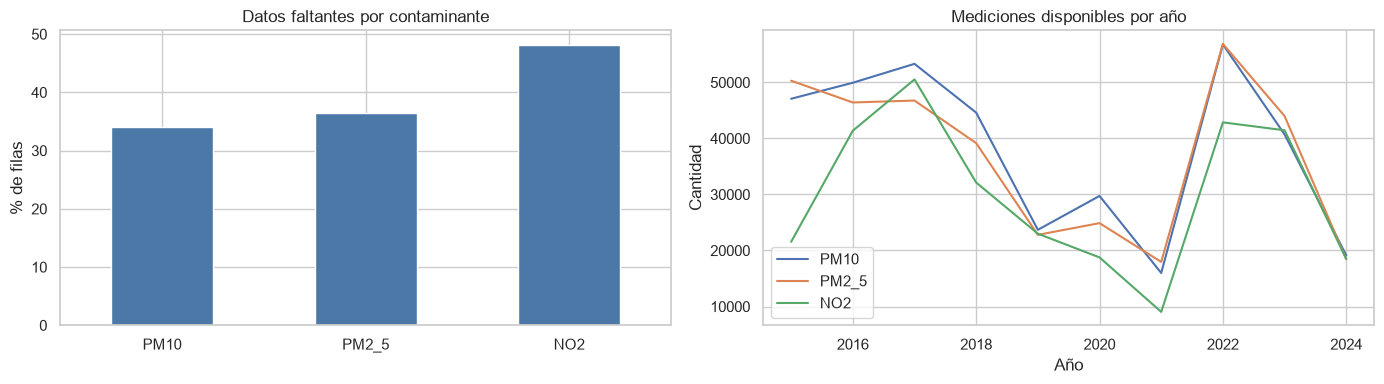

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
PM10,380982.0,61.835134,46.535486,2.31,10.36,30.98,49.84,79.07,145.0,232.5057,974.0
PM2_5,367591.0,24.253347,15.813837,1.73,4.80,13.70,20.30,30.47,53.8,79.3100,720.7
NO2,299192.0,22.532890,14.979673,0.00,1.80,12.00,19.80,29.60,49.9,74.2000,231.2


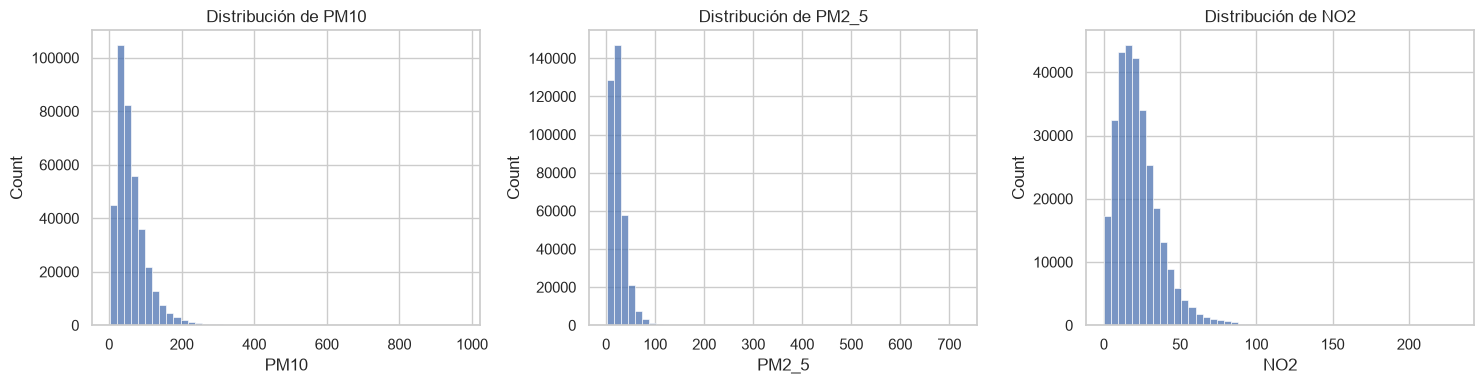

In [3]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
df_raw.columns = df_raw.columns.str.strip()
print(f"Filas: {len(df_raw):,} | columnas: {df_raw.shape[1]}")
print("Fecha mínima/máxima:", df_raw["FECHA"].min(), df_raw["FECHA"].max())
print("Estaciones:", df_raw["ESTACION"].nunique())
display(df_raw.head())
quality = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "nulos": df_raw.isna().sum(),
    "% nulos": (100 * df_raw.isna().mean()).round(2)
})
display(quality)
pollutants = ["PM10", "PM2_5", "NO2"]
display(pd.DataFrame({
    "válidos": df_raw[pollutants].notna().sum(),
    "nulos": df_raw[pollutants].isna().sum(),
    "% nulos": (100 * df_raw[pollutants].isna().mean()).round(2),
    "negativos": (df_raw[pollutants] < 0).sum()
}))
print("Duplicados fila completa:", int(df_raw.duplicated().sum()))
print("Duplicados estación-fecha-hora:", int(df_raw.duplicated(["ESTACION", "FECHA", "HORA"]).sum()))
display(df_raw["ESTACION"].value_counts().rename_axis("estación").to_frame("filas"))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
(100 * df_raw[pollutants].isna().mean()).plot(kind="bar", ax=ax[0], color="#4c78a8")
ax[0].set(title="Datos faltantes por contaminante", ylabel="% de filas", xlabel="")
ax[0].tick_params(axis="x", rotation=0)
year = pd.to_datetime(df_raw["FECHA"].astype("Int64").astype(str), format="%Y%m%d", errors="coerce").dt.year
df_raw.assign(año=year).groupby("año")[pollutants].count().plot(ax=ax[1])
ax[1].set(title="Mediciones disponibles por año", xlabel="Año", ylabel="Cantidad")
plt.tight_layout(); plt.show()
display(df_raw[pollutants].describe(percentiles=[.01, .25, .5, .75, .95, .99]).T)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, pollutants):
    sns.histplot(df_raw[col].dropna(), bins=50, ax=a)
    a.set_title(f"Distribución de {col}")
plt.tight_layout(); plt.show()

**Anota la interpretación:** ¿qué contaminante tiene más nulos?, ¿varía la cobertura entre años?, ¿hay colas largas o valores extremos? Un valor extremo se marca para revisar; no se elimina automáticamente porque podría ser real.

## 4. Limpieza y preparación

In [4]:
df = df_raw.copy()
df["ESTACION"] = df["ESTACION"].astype("string").str.strip().str.upper()
for col in pollutants + ["LONGITUD", "LATITUD", "ALTITUD"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
fecha = pd.to_numeric(df["FECHA"], errors="coerce").astype("Int64").astype("string")
hora = pd.to_numeric(df["HORA"], errors="coerce").astype("Int64").astype("string").str.zfill(6)
df["timestamp"] = pd.to_datetime(fecha + hora, format="%Y%m%d%H%M%S", errors="coerce")
invalid_ts = int(df["timestamp"].isna().sum())
df = df.dropna(subset=["timestamp", "ESTACION"]).drop_duplicates().copy()
group_key = ["ESTACION", "timestamp"]
key_counts = df.groupby(group_key).size()
agg = {c: "median" for c in pollutants}
for c in ["LONGITUD", "LATITUD", "ALTITUD", "DEPARTAMENTO", "PROVINCIA", "DISTRITO", "UBIGEO"]:
    if c in df.columns: agg[c] = "first"
df_clean = df.groupby(group_key, as_index=False).agg(agg)
df_clean["filas_consolidadas"] = df_clean.set_index(group_key).index.map(key_counts).astype(int)
print("Fechas inválidas descartadas:", invalid_ts)
print("Claves estación-hora repetidas consolidadas:", int((key_counts > 1).sum()))
print("Filas limpias:", f"{len(df_clean):,}")
print("Periodo:", df_clean.timestamp.min(), "a", df_clean.timestamp.max())
display(df_clean.head())

Fechas inválidas descartadas: 0
Claves estación-hora repetidas consolidadas: 42
Filas limpias: 577,710
Periodo: 2015-01-01 05:00:00 a 2024-05-31 23:00:00


,ESTACION,timestamp,PM10,PM2_5,NO2,LONGITUD,LATITUD,ALTITUD,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,filas_consolidadas
0,CAMPO_DE_MARTE,2015-01-01 05:00:00,37.92,NaN,NaN,-77.0432,-12.0705,117.0,LIMA,LIMA,JESUS_MARIA,150113.0,1
1,CAMPO_DE_MARTE,2015-01-01 06:00:00,153.39,NaN,NaN,-77.0432,-12.0705,117.0,LIMA,LIMA,JESUS_MARIA,150113.0,1
2,CAMPO_DE_MARTE,2015-01-01 07:00:00,116.49,NaN,NaN,-77.0432,-12.0705,117.0,LIMA,LIMA,JESUS_MARIA,150113.0,1
3,CAMPO_DE_MARTE,2015-01-01 08:00:00,80.74,NaN,NaN,-77.0432,-12.0705,117.0,LIMA,LIMA,JESUS_MARIA,150113.0,1
4,CAMPO_DE_MARTE,2015-01-01 09:00:00,27.40,NaN,NaN,-77.0432,-12.0705,117.0,LIMA,LIMA,JESUS_MARIA,150113.0,1


Las claves repetidas se consolidan con la mediana de las mediciones, después de quitar duplicados exactos. Así evitamos contar dos veces la misma estación-hora; conservamos cuántas filas fueron agregadas.

## 5. Exploración de datos limpios

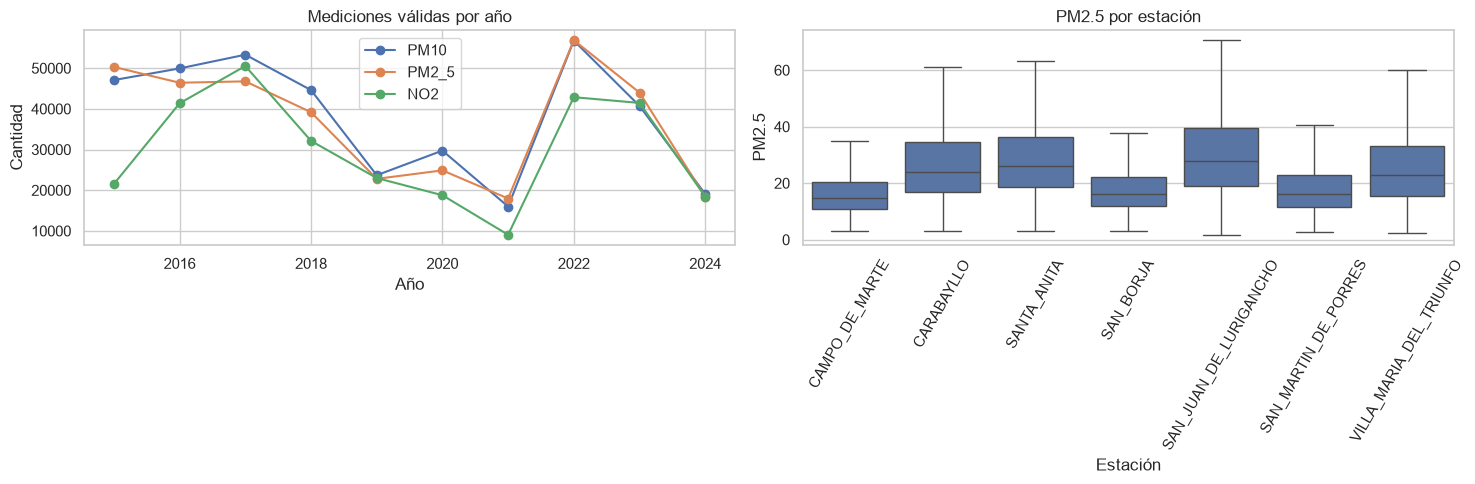

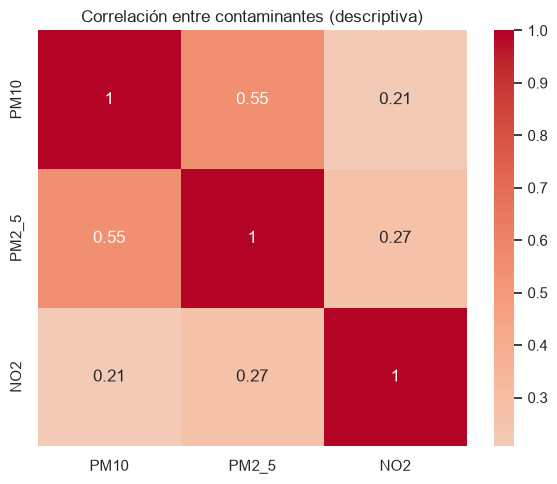

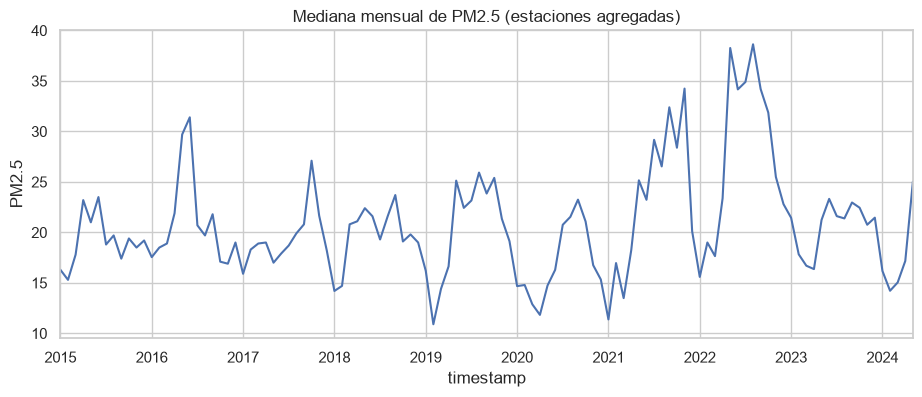

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
df_clean.groupby(df_clean.timestamp.dt.year)[pollutants].count().plot(ax=ax[0], marker="o")
ax[0].set(title="Mediciones válidas por año", xlabel="Año", ylabel="Cantidad")
sns.boxplot(data=df_clean, x="ESTACION", y="PM2_5", ax=ax[1], showfliers=False)
ax[1].set(title="PM2.5 por estación", xlabel="Estación", ylabel="PM2.5")
ax[1].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_clean[pollutants].corr(), annot=True, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlación entre contaminantes (descriptiva)")
plt.tight_layout(); plt.show()
monthly = df_clean.dropna(subset=["PM2_5"]).set_index("timestamp")["PM2_5"].resample("MS").median()
monthly.plot(figsize=(11, 4), title="Mediana mensual de PM2.5 (estaciones agregadas)", ylabel="PM2.5")
plt.show()

Interpreta lo que muestran las figuras. Las correlaciones y patrones temporales son descriptivos, no demuestran causalidad. La serie mensual agrega estaciones y puede ocultar diferencias locales.

## 6. Diseño del experimento principal: regresión

Estimaremos PM2.5 de la misma hora usando estación, hora/día/mes, PM10 y NO2 contemporáneos. Esto es **estimación**, no pronóstico de horas futuras; para pronosticar se necesitarían variables rezagadas. La evaluación usa fechas desde 2023 y el entrenamiento fechas anteriores. No se mezclan aleatoriamente pasado y futuro.

Las filas sin PM2.5, PM10 o NO2 se excluyen solo de este experimento. El entrenamiento y la prueba se limitan a muestras reproducibles para que el notebook pueda ejecutarse en una computadora personal; se informan tanto los totales disponibles como las muestras evaluadas. Métricas: MAE, RMSE y R².

In [6]:
def add_time_features(frame):
    out = frame.copy()
    ts = pd.to_datetime(out["timestamp"])
    out["hora"] = ts.dt.hour
    out["dia_semana"] = ts.dt.dayofweek
    out["mes"] = ts.dt.month
    day = ts.dt.dayofyear
    out["hora_sin"] = np.sin(2*np.pi*out["hora"]/24)
    out["hora_cos"] = np.cos(2*np.pi*out["hora"]/24)
    out["dia_sin"] = np.sin(2*np.pi*day/365.25)
    out["dia_cos"] = np.cos(2*np.pi*day/365.25)
    return out

TARGET = "PM2_5"
FEATURES = ["ESTACION", "PM10", "NO2", "hora", "dia_semana", "mes", "hora_sin", "hora_cos", "dia_sin", "dia_cos"]
CATEGORICAL = ["ESTACION"]
NUMERIC = [c for c in FEATURES if c not in CATEGORICAL]
model_data = add_time_features(df_clean).dropna(subset=[TARGET, "PM10", "NO2"]).copy()
cutoff = pd.Timestamp("2023-01-01")
train_all = model_data[model_data.timestamp < cutoff]
test_all = model_data[model_data.timestamp >= cutoff]
print("Filas completas para modelar:", f"{len(model_data):,}")
print("Entrenamiento disponible:", f"{len(train_all):,}", "| prueba temporal:", f"{len(test_all):,}")
print("Entrenamiento:", train_all.timestamp.min(), "a", train_all.timestamp.max())
print("Prueba:", test_all.timestamp.min(), "a", test_all.timestamp.max())
MAX_TRAIN, MAX_TEST = 30000, 15000
train = train_all.sample(n=min(MAX_TRAIN, len(train_all)), random_state=SEED).sort_values("timestamp")
test = test_all.sample(n=min(MAX_TEST, len(test_all)), random_state=SEED).sort_values("timestamp")
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]
print("Muestra usada para ajustar:", len(train), "| muestra de evaluación:", len(test))

Filas completas para modelar: 209,102
Entrenamiento disponible: 166,568 | prueba temporal: 42,534
Entrenamiento: 2015-02-03 21:00:00 a 2022-12-31 23:00:00
Prueba: 2023-01-01 00:00:00 a 2024-05-31 23:00:00
Muestra usada para ajustar: 30000 | muestra de evaluación: 15000


### Pipeline y modelos de regresión\nEscalado y codificación se ajustan solo en entrenamiento. El pipeline guarda juntos el preprocesamiento y el modelo.

In [7]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("codificar", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL)
])
def make_pipe(model):
    return Pipeline([("preparacion", preprocessor), ("modelo", model)])

regressors = {
    "Regresión lineal": LinearRegression(),
    "KNN regresor": KNeighborsRegressor(n_neighbors=7, weights="distance", n_jobs=-1),
    "Árbol regresor": DecisionTreeRegressor(max_depth=14, min_samples_leaf=5, random_state=SEED),
    "Random Forest regresor": RandomForestRegressor(n_estimators=100, max_depth=18, min_samples_leaf=3, n_jobs=-1, random_state=SEED)
}
regressors["Voting (lineal + Random Forest)"] = VotingRegressor([
    ("lineal", make_pipe(LinearRegression())),
    ("bosque", make_pipe(RandomForestRegressor(n_estimators=100, max_depth=18, min_samples_leaf=3, n_jobs=-1, random_state=SEED)))
])
fitted_regressors = {}
baseline_pred = np.repeat(y_train.mean(), len(y_test))
rows = [{"modelo":"Baseline (media)", "MAE":mean_absolute_error(y_test, baseline_pred),
         "RMSE":mean_squared_error(y_test, baseline_pred)**.5, "R2":r2_score(y_test, baseline_pred)}]
for name, model in regressors.items():
    pipe = model if isinstance(model, VotingRegressor) else make_pipe(model)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted_regressors[name] = pipe
    rows.append({"modelo":name, "MAE":mean_absolute_error(y_test, pred),
                 "RMSE":mean_squared_error(y_test, pred)**.5, "R2":r2_score(y_test, pred)})
regression_results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
display(regression_results.round(3))

,modelo,MAE,RMSE,R2
0,Random Forest regresor,5.165,8.144,0.499
1,Voting (lineal + Random Forest),5.505,8.300,0.480
2,Árbol regresor,6.047,9.385,0.335
3,Regresión lineal,6.748,9.604,0.304
4,KNN regresor,6.823,9.774,0.279
5,Baseline (media),9.325,11.885,-0.067


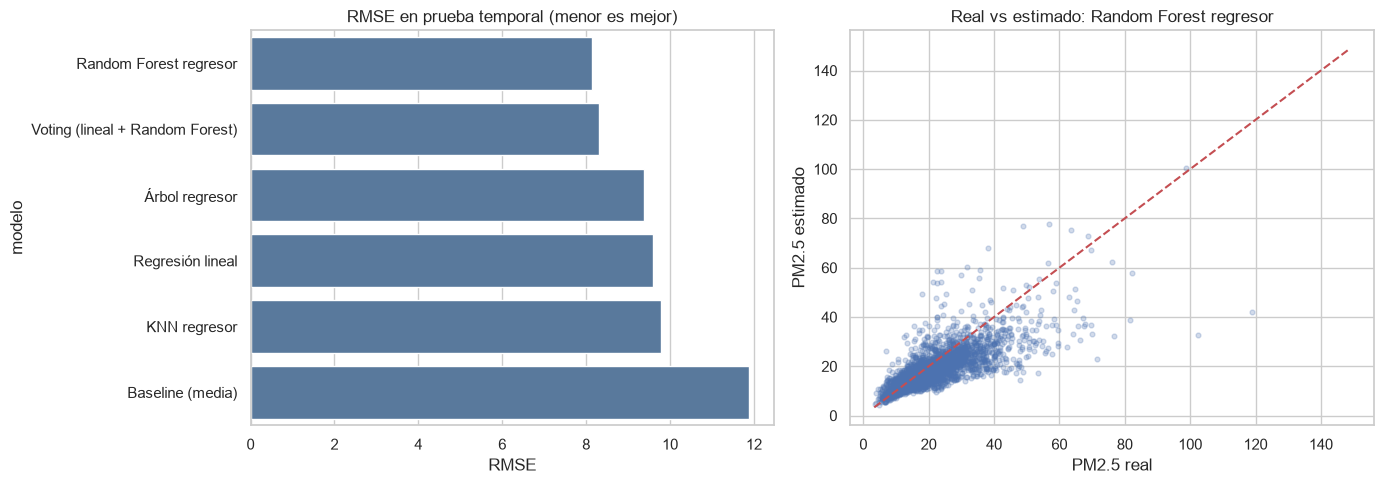

Mejor por RMSE: Random Forest regresor
Compara el ensamble con los modelos individuales; no supongas que siempre será superior.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=regression_results, x="RMSE", y="modelo", color="#4e79a7", ax=ax[0])
ax[0].set_title("RMSE en prueba temporal (menor es mejor)")
best_reg_name = regression_results.loc[regression_results.modelo != "Baseline (media)", "modelo"].iloc[0]
best_reg = fitted_regressors[best_reg_name]
pred = best_reg.predict(X_test)
idx = np.random.default_rng(SEED).choice(len(y_test), min(3000, len(y_test)), replace=False)
ax[1].scatter(y_test.iloc[idx], pred[idx], alpha=.25, s=12)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax[1].plot(lims, lims, "r--")
ax[1].set(title=f"Real vs estimado: {best_reg_name}", xlabel="PM2.5 real", ylabel="PM2.5 estimado")
plt.tight_layout(); plt.show()
print("Mejor por RMSE:", best_reg_name)
print("Compara el ensamble con los modelos individuales; no supongas que siempre será superior.")

### ¿La combinación realmente ayuda?

Voting combina las predicciones de regresión lineal y Random Forest mediante un promedio. Comparamos también los errores de cada componente y qué tan parecidos son. Si ambos suelen equivocarse en los mismos registros, tienen menos para aportarse mutuamente. La medida final es el resultado del Voting frente a cada componente; no basta con que sean algoritmos distintos.

In [9]:
voting_pipe = fitted_regressors["Voting (lineal + Random Forest)"]
voting_estimator = voting_pipe
componentes_voting = voting_estimator.named_estimators_
pred_lineal = componentes_voting["lineal"].predict(X_test)
pred_bosque_voting = componentes_voting["bosque"].predict(X_test)
pred_combinada = voting_pipe.predict(X_test)
comparacion_componentes = pd.DataFrame([
    {"modelo": "Regresión lineal (componente)", "MAE": mean_absolute_error(y_test, pred_lineal),
     "RMSE": mean_squared_error(y_test, pred_lineal)**.5},
    {"modelo": "Random Forest (componente)", "MAE": mean_absolute_error(y_test, pred_bosque_voting),
     "RMSE": mean_squared_error(y_test, pred_bosque_voting)**.5},
    {"modelo": "Voting: promedio de ambos", "MAE": mean_absolute_error(y_test, pred_combinada),
     "RMSE": mean_squared_error(y_test, pred_combinada)**.5}
]).sort_values("RMSE")
display(comparacion_componentes.round(3))
error_corr = np.corrcoef(y_test.to_numpy()-pred_lineal, y_test.to_numpy()-pred_bosque_voting)[0,1]
print(f"Correlación entre los errores de ambos componentes: {error_corr:.3f}")
print("El signo y tamaño de esta correlación ayudan a describir si suelen fallar en los mismos casos.")
print("La tabla decide si el Voting ayudó: compara su RMSE con el de cada componente.")

,modelo,MAE,RMSE
1,Random Forest (componente),5.165,8.144
2,Voting: promedio de ambos,5.505,8.300
0,Regresión lineal (componente),6.748,9.604


Correlación entre los errores de ambos componentes: 0.739
El signo y tamaño de esta correlación ayudan a describir si suelen fallar en los mismos casos.
La tabla decide si el Voting ayudó: compara su RMSE con el de cada componente.


## Prueba adicional: otras formas de combinar modelos

Además del promedio simple Voting, probamos dos combinaciones: (1) mezcla ponderada de pares de regresión lineal, KNN, árbol y Random Forest, eligiendo los pesos con mediciones de 2022; (2) Stacking, donde esos cuatro modelos producen estimaciones y un RidgeCV aprende a combinarlas usando 2022. Los modelos base se entrenan antes de 2022 y la evaluación final usa las mismas fechas de prueba desde 2023. El conjunto final no se usa para elegir los pesos.

La ejecución previa encontró que los pesos de la mejor mezcla daban 0 al segundo modelo (equivale a quedarse con Random Forest), y el Stacking obtuvo RMSE 8.283, frente a 8.144 del Random Forest principal. La siguiente celda repite el experimento y muestra sus métricas. Ninguna mezcla superó al Random Forest en esta evaluación.

In [10]:
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import StackingRegressor

# Bases entrenadas hasta 2021; 2022 sirve para los pesos/meta-modelo; 2023+ queda para evaluación.
exp_train_all = model_data[model_data.timestamp < pd.Timestamp("2022-01-01")]
exp_meta_all = model_data[(model_data.timestamp >= pd.Timestamp("2022-01-01")) &
                          (model_data.timestamp < pd.Timestamp("2023-01-01"))]
exp_train = exp_train_all.sample(n=min(30000, len(exp_train_all)), random_state=SEED).sort_values("timestamp")
exp_meta = exp_meta_all.sample(n=min(15000, len(exp_meta_all)), random_state=SEED).sort_values("timestamp")
X_exp_train, y_exp_train = exp_train[FEATURES], exp_train[TARGET]
X_meta, y_meta = exp_meta[FEATURES], exp_meta[TARGET]
X_exp_test, y_exp_test = X_test, y_test

exp_models = {
    "Regresión lineal": make_pipe(LinearRegression()),
    "KNN regresor": make_pipe(KNeighborsRegressor(n_neighbors=7, weights="distance", n_jobs=-1)),
    "Árbol regresor": make_pipe(DecisionTreeRegressor(max_depth=14, min_samples_leaf=5, random_state=SEED)),
    "Random Forest regresor": make_pipe(RandomForestRegressor(n_estimators=100, max_depth=18, min_samples_leaf=3, n_jobs=-1, random_state=SEED))
}
for name, model in exp_models.items():
    model.fit(X_exp_train, y_exp_train)
exp_meta_pred = {name: model.predict(X_meta) for name, model in exp_models.items()}
exp_test_pred = {name: model.predict(X_exp_test) for name, model in exp_models.items()}

# Buscar el par y peso que da menor RMSE en 2022.
weight_rows = []
exp_names = list(exp_models)
for i in range(len(exp_names)):
    for j in range(i+1, len(exp_names)):
        a, b = exp_names[i], exp_names[j]
        for w in np.linspace(0, 1, 21):
            pred = w*exp_meta_pred[a] + (1-w)*exp_meta_pred[b]
            weight_rows.append((mean_squared_error(y_meta, pred)**.5, a, b, float(w)))
weight_rows.sort(key=lambda row: row[0])
best_blend_val_rmse, blend_a, blend_b, blend_weight = weight_rows[0]
blend_test_pred = blend_weight*exp_test_pred[blend_a] + (1-blend_weight)*exp_test_pred[blend_b]
blend_test_metrics = {"MAE": mean_absolute_error(y_exp_test, blend_test_pred),
                      "RMSE": mean_squared_error(y_exp_test, blend_test_pred)**.5,
                      "R2": r2_score(y_exp_test, blend_test_pred)}

# Stacking: cuatro predictores base; RidgeCV aprende a combinarlos con 2022.
stacking_candidate = StackingRegressor(
    estimators=[(f"base_{i}", model) for i, model in enumerate(exp_models.values())],
    final_estimator=RidgeCV(alphas=[0.1, 1, 10, 100]), cv="prefit", n_jobs=-1
)
stacking_candidate.fit(X_meta, y_meta)
stack_test_pred = stacking_candidate.predict(X_exp_test)
stack_test_metrics = {"MAE": mean_absolute_error(y_exp_test, stack_test_pred),
                      "RMSE": mean_squared_error(y_exp_test, stack_test_pred)**.5,
                      "R2": r2_score(y_exp_test, stack_test_pred)}
rf_main_metrics = regression_results.set_index("modelo").loc["Random Forest regresor", ["MAE", "RMSE", "R2"]].to_dict()
additional_results = pd.DataFrame([
    {"modelo": "Random Forest principal (entrenamiento hasta 2022)", **rf_main_metrics},
    {"modelo": f"Mezcla ponderada: {blend_a} + {blend_b}", **blend_test_metrics},
    {"modelo": "Stacking de 4 modelos + RidgeCV", **stack_test_metrics}
]).sort_values("RMSE")
print(f"Mejor mezcla en validación 2022: {blend_weight:.2f}*{blend_a} + {1-blend_weight:.2f}*{blend_b}; RMSE validación={best_blend_val_rmse:.3f}")
display(additional_results.round(3))

Mejor mezcla en validación 2022: 0.00*Regresión lineal + 1.00*Random Forest regresor; RMSE validación=14.648


,modelo,MAE,RMSE,R2
0,Random Forest principal (entrenamiento hasta 2...,5.165,8.144,0.499
2,Stacking de 4 modelos + RidgeCV,6.064,8.283,0.482
1,Mezcla ponderada: Regresión lineal + Random Fo...,6.486,9.430,0.328


**Interpreta:** ¿qué modelo superó al baseline?, ¿cuál obtuvo menor MAE/RMSE?, ¿qué tan grandes son sus errores frente al rango de PM2.5?, ¿el gráfico se aparta de la diagonal en valores altos?

## 7. Clasificación complementaria y modelos del curso

Para practicar regresión logística, KNN, árbol y Random Forest clasificadores, definimos “PM2.5 relativamente alto” usando el percentil 75 del entrenamiento. Es un umbral exploratorio del dataset, **no un estándar sanitario**. El ensamble Voting combina regresión logística y Random Forest. Se comparan también contra un baseline de clase mayoritaria.

In [11]:
threshold = float(train_all[TARGET].quantile(.75))
y_train_cls = (y_train >= threshold).astype(int)
y_test_cls = (y_test >= threshold).astype(int)
print(f"Umbral p75 del entrenamiento: {threshold:.2f}")
print("Proporción alta train/test:", round(y_train_cls.mean(),3), round(y_test_cls.mean(),3))
classifiers = {
    "Regresión logística": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "KNN clasificador": KNeighborsClassifier(n_neighbors=7, weights="distance", n_jobs=-1),
    "Árbol clasificador": DecisionTreeClassifier(max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=SEED),
    "Random Forest clasificador": RandomForestClassifier(n_estimators=100, max_depth=18, min_samples_leaf=3,
         class_weight="balanced", n_jobs=-1, random_state=SEED)
}
classifiers["Voting (logística + Random Forest)"] = VotingClassifier([
    ("logistica", make_pipe(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED))),
    ("bosque", make_pipe(RandomForestClassifier(n_estimators=100, max_depth=18, min_samples_leaf=3,
         class_weight="balanced", n_jobs=-1, random_state=SEED)))
], voting="soft")
majority = int(y_train_cls.mean() >= .5)
base = np.repeat(majority, len(y_test_cls))
class_rows = [{"modelo":"Baseline (clase mayoritaria)", "Accuracy":accuracy_score(y_test_cls, base),
 "Precision":precision_score(y_test_cls, base, zero_division=0), "Recall":recall_score(y_test_cls, base, zero_division=0),
 "F1":f1_score(y_test_cls, base, zero_division=0), "ROC_AUC":np.nan, "PR_AUC":np.nan}]
fitted_classifiers = {}
for name, model in classifiers.items():
    pipe = model if isinstance(model, VotingClassifier) else make_pipe(model)
    pipe.fit(X_train, y_train_cls)
    pred, proba = pipe.predict(X_test), pipe.predict_proba(X_test)[:,1]
    fitted_classifiers[name] = pipe
    class_rows.append({"modelo":name, "Accuracy":accuracy_score(y_test_cls,pred),
        "Precision":precision_score(y_test_cls,pred,zero_division=0), "Recall":recall_score(y_test_cls,pred,zero_division=0),
        "F1":f1_score(y_test_cls,pred,zero_division=0), "ROC_AUC":roc_auc_score(y_test_cls,proba),
        "PR_AUC":average_precision_score(y_test_cls,proba)})
classification_results = pd.DataFrame(class_rows).sort_values("F1", ascending=False).reset_index(drop=True)
display(classification_results.round(3))

Umbral p75 del entrenamiento: 31.70
Proporción alta train/test: 0.25 0.156


,modelo,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest clasificador,0.894,0.710,0.548,0.618,0.933,0.678
1,Voting (logística + Random Forest),0.888,0.708,0.483,0.574,0.920,0.677
2,Árbol clasificador,0.857,0.542,0.532,0.537,0.843,0.522
3,Regresión logística,0.839,0.483,0.465,0.474,0.839,0.514
4,KNN clasificador,0.843,0.494,0.317,0.386,0.765,0.404
5,Baseline (clase mayoritaria),0.844,0.000,0.000,0.000,NaN,NaN


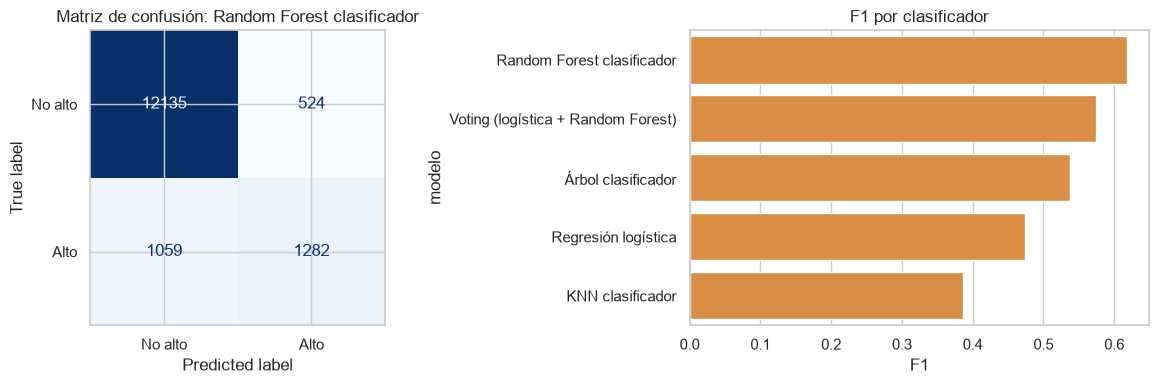

Mejor F1: Random Forest clasificador | esta clase alta es relativa, no sanitaria.


In [23]:
best_cls_name = classification_results.loc[classification_results.modelo != "Baseline (clase mayoritaria)", "modelo"].iloc[0]
best_cls = fitted_classifiers[best_cls_name]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test_cls, best_cls.predict(X_test),
    display_labels=["No alto", "Alto"], cmap="Blues", ax=ax[0], colorbar=False)
ax[0].set_title(f"Matriz de confusión: {best_cls_name}")
sns.barplot(data=classification_results[classification_results.modelo != "Baseline (clase mayoritaria)"],
    x="F1", y="modelo", color="#f28e2b", ax=ax[1])
ax[1].set_title("F1 por clasificador")
plt.tight_layout(); plt.show()
print("Mejor F1:", best_cls_name, "| esta clase alta es relativa, no sanitaria.")

## 8. K-Means como análisis complementario

K-Means agrupa mediciones sin etiquetas y no compite con la regresión. Se estandarizan PM10, PM2.5 y NO2 porque el algoritmo usa distancias. Se analiza una muestra reproducible.

,k,inercia,silhouette
0,2,29550.553,0.425
1,3,23440.082,0.342
2,4,19630.980,0.333
3,5,17129.608,0.328
4,6,15196.800,0.289


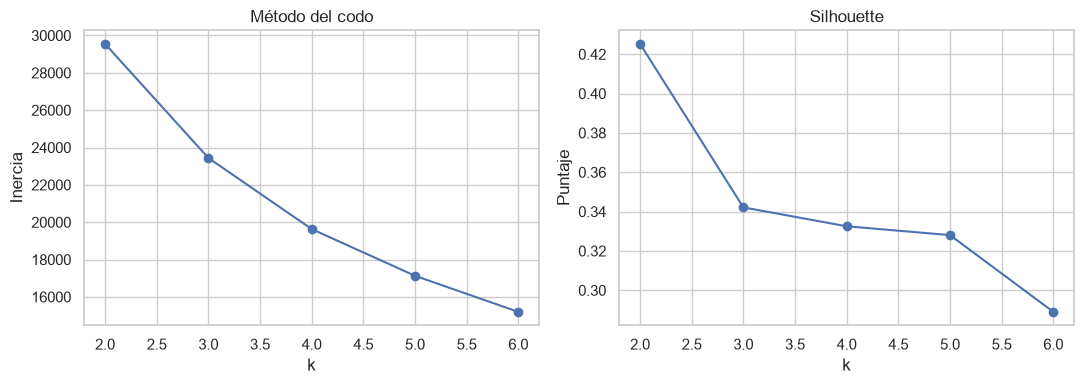

,PM10,PM2_5,NO2
cluster,,,
0,96.70,38.70,31.4
1,40.91,17.18,17.0


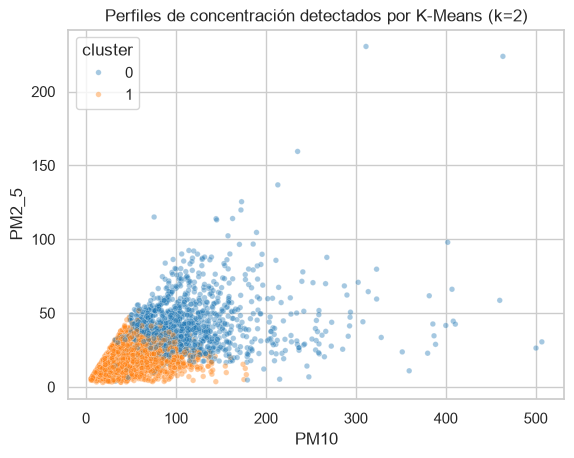

Los clusters son etiquetas arbitrarias; describe sus medianas, no como categorías oficiales.


In [12]:
cluster_data = df_clean.dropna(subset=pollutants)[pollutants]
cluster_sample = cluster_data.sample(n=min(15000, len(cluster_data)), random_state=SEED)
Z = StandardScaler().fit_transform(cluster_sample)
cluster_rows, cluster_models = [], {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(Z)
    cluster_models[k] = km
    cluster_rows.append({"k":k, "inercia":km.inertia_, "silhouette":silhouette_score(Z, labels)})
cluster_results = pd.DataFrame(cluster_rows)
display(cluster_results.round(3))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(cluster_results.k, cluster_results.inercia, marker="o"); ax[0].set(title="Método del codo", xlabel="k", ylabel="Inercia")
ax[1].plot(cluster_results.k, cluster_results.silhouette, marker="o"); ax[1].set(title="Silhouette", xlabel="k", ylabel="Puntaje")
plt.tight_layout(); plt.show()
k_best = int(cluster_results.loc[cluster_results.silhouette.idxmax(), "k"])
cluster_sample = cluster_sample.copy()
cluster_sample["cluster"] = cluster_models[k_best].labels_
display(cluster_sample.groupby("cluster")[pollutants].median().round(2))
sns.scatterplot(data=cluster_sample.sample(n=min(5000,len(cluster_sample)), random_state=SEED),
    x="PM10", y="PM2_5", hue="cluster", palette="tab10", alpha=.4, s=16)
plt.title(f"Perfiles de concentración detectados por K-Means (k={k_best})"); plt.show()
print("Los clusters son etiquetas arbitrarias; describe sus medianas, no como categorías oficiales.")

## 9. Interpretabilidad básica

Importancia por permutación estima cuánto empeora el modelo si se mezcla una variable. Describe el modelo, no demuestra causalidad.

,importancia por permutación
dia_sin,-0.0097
dia_semana,0.0220
hora_sin,0.0492
NO2,0.0501
mes,0.0535
dia_cos,0.1147
hora,0.2073
hora_cos,0.2463
ESTACION,1.4517
PM10,4.2881


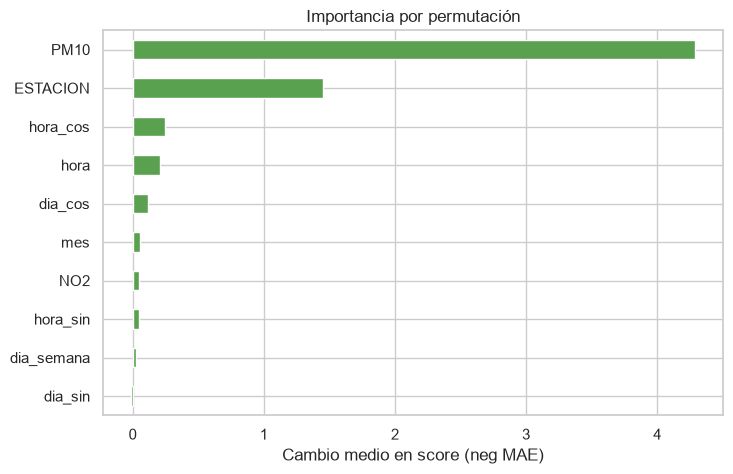

In [13]:
rf_pipe = fitted_regressors["Random Forest regresor"]
n_imp = min(3000, len(X_test))
idx_imp = np.random.default_rng(SEED).choice(len(X_test), n_imp, replace=False)
perm = permutation_importance(rf_pipe, X_test.iloc[idx_imp], y_test.iloc[idx_imp],
    n_repeats=3, random_state=SEED, scoring="neg_mean_absolute_error", n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
display(importance.rename("importancia por permutación").to_frame().round(4))
importance.plot(kind="barh", figsize=(8,5), color="#59a14f")
plt.title("Importancia por permutación"); plt.xlabel("Cambio medio en score (neg MAE)"); plt.show()

## Guardar el modelo elegido

En esta ejecución, el Random Forest individual fue mejor que las combinaciones ensayadas. Por eso el joblib de uso guardará ese modelo y su preprocesamiento, junto con una ficha que registra Voting, mezcla ponderada y Stacking y explica por qué no se eligieron. Si una combinación supera al mejor modelo en una evaluación futura, podremos cambiar la selección y guardar el ensamble con sus componentes.

In [14]:
best_reg_name = regression_results.loc[regression_results.modelo != "Baseline (media)", "modelo"].iloc[0]
metrics_lookup = regression_results.set_index("modelo")
voting_metrics = metrics_lookup.loc["Voting (lineal + Random Forest)", ["MAE", "RMSE", "R2"]].to_dict()
model_card = {
    "fuente": "SENAMHI / Plataforma Nacional de Datos Abiertos",
    "archivo": DATA_PATH.name, "objetivo": TARGET, "variables": FEATURES,
    "modelo_guardado": best_reg_name,
    "metricas_modelo_guardado": metrics_lookup.loc[best_reg_name, ["MAE", "RMSE", "R2"]].to_dict(),
    "combinaciones_probadas": {
        "Voting_lineal_mas_RF": {**voting_metrics, "correlacion_errores": float(error_corr),
            "explicacion": "No supera al RF solo; los errores de sus componentes se parecen."},
        "mezcla_ponderada": {"par_elegido_en_validacion": [blend_a, blend_b], "peso_primero": blend_weight,
            "RMSE_validacion": float(best_blend_val_rmse), **{k: float(v) for k,v in blend_test_metrics.items()},
            "explicacion": "La validacion asigno peso cero al segundo modelo; la mezcla efectiva fue un modelo individual."},
        "stacking_4_modelos_RidgeCV": {**{k: float(v) for k,v in stack_test_metrics.items()},
            "explicacion": "No supera al RF principal en la prueba temporal."}
    },
    "corte_temporal": str(cutoff.date()), "filas_entrenamiento": int(len(train)),
    "filas_prueba": int(len(test)), "semilla": SEED,
    "pandas": pd.__version__, "scikit_learn": sklearn.__version__
}
models_to_save = {"mejor_individual": fitted_regressors[best_reg_name]}
joblib.dump({"modelos": models_to_save, "ficha": model_card}, MODEL_PATH)
with open(OUTPUT_DIR / "ficha_modelo.json", "w", encoding="utf-8") as f:
    json.dump(model_card, f, ensure_ascii=False, indent=2)
artifact = joblib.load(MODEL_PATH)
demo = X_test.iloc[:5].copy()
demo["PM2_5_estimado"] = artifact["modelos"]["mejor_individual"].predict(X_test.iloc[:5][FEATURES])
demo["PM2_5_real"] = y_test.iloc[:5].to_numpy()
display(demo[["ESTACION", "PM10", "NO2", "PM2_5_estimado", "PM2_5_real"]])
print("Modelo individual guardado:", best_reg_name)
print("Archivo:", MODEL_PATH)
print(json.dumps(model_card, ensure_ascii=False, indent=2))

,ESTACION,PM10,NO2,PM2_5_estimado,PM2_5_real
317713,SAN_BORJA,28.35,14.5,10.208499,11.42
70123,CAMPO_DE_MARTE,17.37,8.4,10.553970,10.44
70124,CAMPO_DE_MARTE,16.47,9.4,10.120421,10.92
235185,SANTA_ANITA,80.70,12.1,37.192990,29.59
317715,SAN_BORJA,51.10,17.2,14.257386,22.35


Modelo individual guardado: Random Forest regresor
Archivo: C:\Users\Robert Herrera\escritorio\Desktop\IA PARCIAL\resultados_senamhi\models\modelo_pm25_senamhi.joblib
{
  "fuente": "SENAMHI / Plataforma Nacional de Datos Abiertos",
  "archivo": "Monitoreo de los contaminantes del aire en Lima Metropolitana - [Servicio Nacional de Meteorología e Hidrología del Perú - SENAMHI]_1.csv",
  "objetivo": "PM2_5",
  "variables": [
    "ESTACION",
    "PM10",
    "NO2",
    "hora",
    "dia_semana",
    "mes",
    "hora_sin",
    "hora_cos",
    "dia_sin",
    "dia_cos"
  ],
  "modelo_guardado": "Random Forest regresor",
  "metricas_modelo_guardado": {
    "MAE": 5.165408541118097,
    "RMSE": 8.144146845742974,
    "R2": 0.4991562399748508
  },
  "combinaciones_probadas": {
    "Voting_lineal_mas_RF": {
      "MAE": 5.5045686129276445,
      "RMSE": 8.29967886424771,
      "R2": 0.47984395109509914,
      "correlacion_errores": 0.7389936630713497,
      "explicacion": "No supera al RF solo; los

In [18]:
def preparar_nuevos_registros(nuevos):
    requeridas = ["ESTACION", "FECHA", "HORA", "PM10", "NO2"]
    faltan = [c for c in requeridas if c not in nuevos.columns]
    if faltan:
        raise ValueError(f"Faltan columnas: {faltan}")
    frame = nuevos.copy()
    fecha = pd.to_numeric(frame["FECHA"], errors="coerce").astype("Int64").astype("string")
    hora = pd.to_numeric(frame["HORA"], errors="coerce").astype("Int64").astype("string").str.zfill(6)
    frame["timestamp"] = pd.to_datetime(fecha + hora, format="%Y%m%d%H%M%S", errors="coerce")
    frame["ESTACION"] = frame["ESTACION"].astype("string").str.strip().str.upper()
    for c in ["PM10", "NO2"]:
        frame[c] = pd.to_numeric(frame[c], errors="coerce")
    if frame[["timestamp", "ESTACION", "PM10", "NO2"]].isna().any().any():
        raise ValueError("Hay fecha, estación, PM10 o NO2 vacío/inválido.")
    return add_time_features(frame)

def predecir_pm25(nuevos, nombre_modelo=None, ruta_modelo=MODEL_PATH):
    frame = preparar_nuevos_registros(nuevos)
    artifact = joblib.load(ruta_modelo)
    if nombre_modelo is None:
        nombre_modelo = "mejor_individual"
    if nombre_modelo not in artifact["modelos"]:
        raise ValueError(f"Elige uno de estos modelos: {list(artifact['modelos'])}")
    resultado = nuevos.copy()
    resultado["PM2_5_estimado"] = artifact["modelos"][nombre_modelo].predict(
        frame[artifact["ficha"]["variables"]]
    )
    resultado["modelo_usado"] = nombre_modelo
    return resultado

# Ejemplo: usa el Random Forest que quedó guardado como mejor modelo.
ejemplo = test.iloc[[0]][["ESTACION", "PM10", "NO2", "timestamp"]].copy()
ejemplo["FECHA"] = ejemplo["timestamp"].dt.strftime("%Y%m%d").astype(int)
ejemplo["HORA"] = ejemplo["timestamp"].dt.strftime("%H%M%S").astype(int)
ent = ejemplo[["ESTACION", "FECHA", "HORA", "PM10", "NO2"]]
display(predecir_pm25(ent, nombre_modelo="mejor_individual"))

,ESTACION,FECHA,HORA,PM10,NO2,PM2_5_estimado,modelo_usado
317713,SAN_BORJA,20230101,0,28.35,14.5,10.208499,mejor_individual


## 11. Resultados, limitaciones y reproducibilidad para el informe

Después de ejecutar, utiliza las tablas y gráficos para completar:

- **Datos:** SENAMHI, periodo y estaciones; filas originales y filas utilizables.
- **Calidad:** faltantes, duplicados consolidados, cambios de cobertura y extremos observados.
- **Experimento:** corte temporal, tamaño de muestras, variables, semilla y versiones impresas arriba.
- **Resultados:** comparación con baseline; MAE/RMSE/R² para regresión y precision/recall/F1/PR-AUC para clasificación.
- **Ensamble:** indica si Voting mejoró o no frente a sus modelos individuales.
- **Modelo reutilizable:** se guarda un solo regresor cuando supera las combinaciones probadas; la ficha del joblib conserva sus métricas y explica por qué Voting, mezcla ponderada y Stacking no se eligieron.

**Limitaciones:** el CSV descargado termina en mayo de 2024; los nulos reducen las filas utilizables; la evaluación temporal no demuestra generalización a otras ciudades o estaciones; se estima PM2.5 con otras mediciones de la misma hora, no se predicen horas futuras; “alto” se define por un percentil interno y no por un estándar sanitario. No se usan datos personales. Atribuye los datos a SENAMHI y conserva el diccionario y metadatos.

**Conclusión (completar luego de ejecutar):** responde qué modelo superó al baseline, con qué métrica, si el Voting aportó mejora y qué limitaciones impiden afirmar más. No escribas resultados anticipados.